# Clasificación Binaria con Redes Neuronales en PyTorch

Este cuadernillo es una adaptación del laboratorio de **Regresión Logística** tradicional a **Redes Neuronales con PyTorch**.

## Objetivos:
- Implementar clasificación binaria usando `torch.nn`
- Utilizar `Dataset` y `DataLoader` para manejo de datos
- Implementar **checkpoints** para guardar/cargar modelos
- Clasificar eventos del experimento MiniBooNE (Señal vs Fondo)

## Dataset MiniBooNE:
- **50 características** de sensores de un experimento de física de partículas
- **Clase 1 (Señal)**: Eventos de interés (neutrinos)
- **Clase 0 (Fondo)**: Ruido/eventos no deseados

## 1. Configuración del Entorno e Importación de Librerías

In [ ]:
# Instalar imblearn si no está instalado
!pip install imbalanced-learn -q

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE  # Para balanceo de clases

# Verificar si hay GPU disponible
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Usando dispositivo: {device}")

Usando dispositivo: cuda


## 2. Carga y Exploración de Datos

In [ ]:
# Montar Google Drive (si estás en Colab)
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Definir la ruta del dataset
ruta_dataset = '/content/drive/MyDrive/Colab Notebooks/sis420/Laboratorios/Lab 3/MiniBooNE_PID.txt'

# Leer la primera línea para obtener la cantidad de señales y fondo
with open(ruta_dataset, 'r') as file:
    primera_linea = file.readline().strip()
    num_senales, num_fondo = map(int, primera_linea.split())

print(f"Señales (clase 1): {num_senales}")
print(f"Fondo (clase 0): {num_fondo}")
print(f"Total de muestras: {num_senales + num_fondo}")

Señales (clase 1): 36499
Fondo (clase 0): 93565
Total de muestras: 130064


In [ ]:
# Cargar las 50 características usando Pandas
print("Cargando dataset...")
df = pd.read_csv(ruta_dataset, delim_whitespace=True, skiprows=1, header=None)

# Añadir las etiquetas como una nueva columna
# Las primeras num_senales filas son clase 1, el resto clase 0
df['Etiqueta'] = [1] * num_senales + [0] * num_fondo

print(f"\nDimensiones del dataset: {df.shape}")
print(f"Características: {df.shape[1] - 1}")

Cargando dataset...


/tmp/ipykernel_662/3105847433.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(ruta_dataset, delim_whitespace=True, skiprows=1, header=None)



Dimensiones del dataset: (130064, 51)
Características: 50


In [ ]:
# Verificar datos nulos
nulos_totales = df.isnull().sum().sum()
print(f"Valores nulos encontrados: {x}")

if nulos_totales > 0:
    print("Rellenando nulos con la media de cada columna...")
    df = df.fillna(df.mean())
else:
    print("¡Dataset limpio! No hay valores faltantes.")

Valores nulos encontrados: 0
¡Dataset limpio! No hay valores faltantes.



Distribución de clases:
Etiqueta
0    93565
1    36499
Name: count, dtype: int64


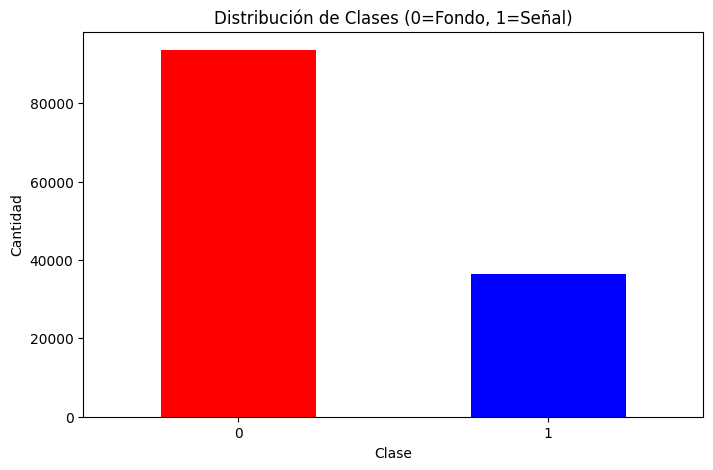

In [ ]:
# Visualizar distribución de clases
print("\nDistribución de clases:")
print(df['Etiqueta'].value_counts())

plt.figure(figsize=(8, 5))
df['Etiqueta'].value_counts().plot(kind='bar', color=['red', 'blue'])
plt.xlabel('Clase')
plt.ylabel('Cantidad')
plt.title('Distribución de Clases (0=Fondo, 1=Señal)')
plt.xticks(rotation=0)
plt.show()

## 3. Preparación de Datos

In [ ]:
# Separar características (X) y etiquetas (y)
X_completo = df.drop('Etiqueta', axis=1).values.astype(np.float32)
y_completo = df['Etiqueta'].values.astype(np.float32).reshape(-1, 1)  # Reshape para BCELoss

print(f"Forma de X: {X_completo.shape}")
print(f"Forma de y: {y_completo.shape}")

Forma de X: (130064, 50)
Forma de y: (130064, 1)


In [ ]:
# Función de normalización Z-score
def normalizar(data):
    """
    Normaliza los datos usando Z-score: z = (x - mu) / sigma
    """
    mu = np.mean(data, axis=0)
    sigma = np.std(data, axis=0)
    # Evitar división por cero
    sigma[sigma == 0] = 1
    data_norm = (data - mu) / sigma
    return data_norm, mu, sigma

# Normalizar solo X (las etiquetas y son 0 o 1, no se normalizan)
X_norm, mu_X, sigma_X = normalizar(X_completo)

print(f"Media de X (primeras 5): {mu_X[:5]}")
print(f"Sigma de X (primeras 5): {sigma_X[:5]}")

Media de X (primeras 5): [  1.2517995  -2.1075509 123.79504    -3.3125184  -3.5853531]
Sigma de X (primeras 5): [ 60.119755  59.91286  196.00995   59.834324  59.817905]


In [ ]:
# ============================================================
# BALANCEO DE CLASES CON SMOTE
# ============================================================
# Meta: 40,000 ejemplos por clase = 80,000 total
#
# SMOTE (Synthetic Minority Over-sampling Technique):
# - Genera ejemplos sintéticos para clases minoritarias
# - Interpola entre ejemplos existentes de la misma clase
# - Mejor que duplicar porque crea variedad
# ============================================================

MUESTRAS_POR_CLASE = 40000

print("Distribución ANTES del balanceo:")
print(f"  Señal (1): {np.sum(y_completo == 1)}")
print(f"  Fondo (0): {np.sum(y_completo == 0)}")

# Paso 1: Reducir clases mayoritarias a 40,000 (undersampling manual)
# Paso 2: Aumentar clases minoritarias a 40,000 con SMOTE (oversampling)

np.random.seed(42)

# Primero hacemos undersampling manual de las clases mayoritarias
indices_por_clase = []
for i in range(2):  # 2 clases: 0 y 1
    idx_clase = np.where(y_completo.ravel() == i)[0]
    if len(idx_clase) > MUESTRAS_POR_CLASE:
        # Undersampling: tomar solo 40,000 aleatorios
        idx_clase = np.random.choice(idx_clase, MUESTRAS_POR_CLASE, replace=False)
    indices_por_clase.append(idx_clase)

# Combinar índices seleccionados
indices_seleccionados = np.concatenate(indices_por_clase)
X_temp = X_norm[indices_seleccionados]
y_temp = y_completo.ravel()[indices_seleccionados]

print(f"\nDespués de undersampling:")
print(f"  Señal (1): {np.sum(y_temp == 1)}")
print(f"  Fondo (0): {np.sum(y_temp == 0)}")

# Ahora aplicamos SMOTE para aumentar clases minoritarias a 40,000
smote = SMOTE(
    sampling_strategy={0: MUESTRAS_POR_CLASE, 1: MUESTRAS_POR_CLASE},
    random_state=42,
    k_neighbors=5  # Número de vecinos para interpolación
)

X_balanceado, y_balanceado = smote.fit_resample(X_temp, y_temp)

# Convertir y a shape (n, 1) para BCELoss
y_balanceado = y_balanceado.reshape(-1, 1).astype(np.float32)

print(f"\nDistribución DESPUÉS del balanceo con SMOTE:")
print(f"  Señal (1): {np.sum(y_balanceado == 1)}")
print(f"  Fondo (0): {np.sum(y_balanceado == 0)}")
print(f"\nTotal de ejemplos: {len(y_balanceado)} (80,000 = 40k + 40k)")

Distribución ANTES del balanceo:
  Señal (1): 36499
  Fondo (0): 93565

Después de undersampling:
  Señal (1): 36499
  Fondo (0): 40000

Distribución DESPUÉS del balanceo con SMOTE:
  Señal (1): 40000
  Fondo (0): 40000

Total de ejemplos: 80000 (80,000 = 40k + 40k)


In [ ]:
# ============================================================
# DIVISIÓN 70/20/10 PARA EVITAR DATA LEAKAGE
# ============================================================
# - 70% Entrenamiento: para entrenar el modelo
# - 20% Validación: para seleccionar checkpoints (durante entrenamiento)
# - 10% Test: evaluación FINAL (solo al final, nunca durante entrenamiento)
# ============================================================

# Primero separamos 10% para test
X_temp, X_test, y_temp, y_test = train_test_split(
    X_balanceado, y_balanceado,
    test_size=0.10,
    random_state=42,
    stratify=y_balanceado
)

# Del 90% restante: 70% train, 20% validación (20/90 ≈ 0.222)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.222,
    random_state=42,
    stratify=y_temp
)

print("División de datos (70/20/10):")
print(f"  Entrenamiento: {X_train.shape[0]} ({100*X_train.shape[0]/len(y_balanceado):.1f}%)")
print(f"  Validación:    {X_val.shape[0]} ({100*X_val.shape[0]/len(y_balanceado):.1f}%)")
print(f"  Test (final):  {X_test.shape[0]} ({100*X_test.shape[0]/len(y_balanceado):.1f}%)")

print(f"\nBalance en cada conjunto:")
print(f"  Train - Señal: {np.sum(y_train==1)}, Fondo: {np.sum(y_train==0)}")
print(f"  Val   - Señal: {np.sum(y_val==1)}, Fondo: {np.sum(y_val==0)}")
print(f"  Test  - Señal: {np.sum(y_test==1)}, Fondo: {np.sum(y_test==0)}")

División de datos (70/20/10):
  Entrenamiento: 56016 (70.0%)
  Validación:    15984 (20.0%)
  Test (final):  8000 (10.0%)

Balance en cada conjunto:
  Train - Señal: 28008, Fondo: 28008
  Val   - Señal: 7992, Fondo: 7992
  Test  - Señal: 4000, Fondo: 4000


## 4. Creación del Dataset Personalizado (PyTorch)

In [ ]:
class MiniBooNEDataset(torch.utils.data.Dataset):
    """
    Dataset personalizado para datos de MiniBooNE.
    Hereda de torch.utils.data.Dataset
    """
    def __init__(self, X, y):
        """
        Constructor: convierte numpy arrays a tensores de PyTorch
        """
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).float()

    def __len__(self):
        """
        Retorna el número de muestras en el dataset
        """
        return len(self.X)

    def __getitem__(self, idx):
        """
        Retorna una muestra específica (X, y) dado un índice
        """
        return self.X[idx], self.y[idx]

In [ ]:
# Crear datasets para train, validación y test
train_dataset = MiniBooNEDataset(X_train, y_train)
val_dataset = MiniBooNEDataset(X_val, y_val)
test_dataset = MiniBooNEDataset(X_test, y_test)

print(f"Tamaño del dataset de entrenamiento: {len(train_dataset)}")
print(f"Tamaño del dataset de validación: {len(val_dataset)}")
print(f"Tamaño del dataset de prueba (final): {len(test_dataset)}")

# Verificar una muestra
sample_x, sample_y = train_dataset[0]
print(f"\nMuestra - X shape: {sample_x.shape}, y: {sample_y.item()}")

Tamaño del dataset de entrenamiento: 56016
Tamaño del dataset de validación: 15984
Tamaño del dataset de prueba (final): 8000

Muestra - X shape: torch.Size([50]), y: 0.0


## 5. Creación de DataLoaders

In [ ]:
# Hiperparámetros
BATCH_SIZE = 512

# Crear DataLoaders
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True  # Mezclar datos en cada epoch
)

# val_loader: para selección de modelo (checkpoints)
val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# test_loader: SOLO para evaluación final (evita data leakage)
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Verificar un batch
x_batch, y_batch = next(iter(train_loader))
print(f"Batch X shape: {x_batch.shape}")
print(f"Batch y shape: {y_batch.shape}")

Batch X shape: torch.Size([512, 50])
Batch y shape: torch.Size([512, 1])


## 6. Definición del Modelo de Red Neuronal

Para **Clasificación Binaria**, usamos:
- Capa lineal de entrada → capas ocultas → capa de salida
- **Sigmoid** en la salida para obtener probabilidades entre 0 y 1
- **BCELoss** (Binary Cross Entropy) como función de pérdida

In [ ]:
class ClasificadorBinarioNN(nn.Module):
    """
    Red Neuronal para Clasificación Binaria con técnicas anti-overfitting.

    Mejoras aplicadas:
    - Dropout: Desactiva neuronas aleatoriamente (evita memorización)
    - BatchNorm: Normaliza activaciones (entrenamiento más estable)
    """
    def __init__(self, n_features, dropout_rate=0.3):
        super(ClasificadorBinarioNN, self).__init__()

        self.red = nn.Sequential(
            # Capa 1: entrada → 64 neuronas
            nn.Linear(n_features, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            # Capa 2: 64 → 32 neuronas
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout_rate * 0.5),  # Menos dropout cerca de salida

            # Capa de salida (1 neurona para binario)
            nn.Linear(32, 1),
            nn.Sigmoid()  # Convierte a probabilidad [0, 1]
        )

    def forward(self, x):
        return self.red(x)

In [ ]:
# Número de características (50 sensores)
n_features = X_train.shape[1]
print(f"Número de características: {n_features}")

# Crear el modelo y moverlo al dispositivo (GPU/CPU)
model = ClasificadorBinarioNN(n_features).to(device)
print(f"\nArquitectura del modelo:")
print(model)

Número de características: 50

Arquitectura del modelo:
ClasificadorBinarioNN(
  (red): Sequential(
    (0): Linear(in_features=50, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.15, inplace=False)
    (8): Linear(in_features=32, out_features=1, bias=True)
    (9): Sigmoid()
  )
)


## 7. Configuración del Entrenamiento

Para clasificación binaria usamos:
- **BCELoss**: Binary Cross Entropy (pérdida de entropía cruzada binaria)
- **Adam**: Optimizador adaptativo (mejor que SGD para este caso)

In [ ]:
# Hiperparámetros de entrenamiento
LEARNING_RATE = 0.001
EPOCHS = 500  # Más épocas porque tenemos early stopping
WEIGHT_DECAY = 1e-4  # Regularización L2

# Función de pérdida: Binary Cross Entropy
criterion = nn.BCELoss()

# Optimizador con weight_decay (regularización L2)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# Scheduler: reduce learning rate cuando val_loss no mejora
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5
)

print(f"Learning Rate inicial: {LEARNING_RATE}")
print(f"Weight Decay (L2): {WEIGHT_DECAY}")
print(f"Epochs máximos: {EPOCHS}")
print(f"Scheduler: ReduceLROnPlateau")

Learning Rate inicial: 0.001
Weight Decay (L2): 0.0001
Epochs máximos: 500
Scheduler: ReduceLROnPlateau


## 8. Bucle de Entrenamiento con Checkpoints

In [ ]:
def entrenar(model, train_loader, val_loader, criterion, optimizer, epochs, device,
             checkpoint_path="./mejor_modelo_binario.pt", patience=15, scheduler=None):
    """
    Función de entrenamiento con:
    - Checkpoints (guarda mejor modelo por val_loss)
    - Early Stopping (detiene si no mejora)
    - Learning Rate Scheduler (reduce LR adaptivamente)
    """
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    best_val_loss = float('inf')
    epochs_sin_mejora = 0
    mejor_epoca = 0

    for epoch in range(1, epochs + 1):
        # --- ENTRENAMIENTO ---
        model.train()
        epoch_train_loss = []
        epoch_train_correct = 0
        epoch_train_total = 0

        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            y_pred = model(x_batch)
            loss = criterion(y_pred, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_train_loss.append(loss.item())
            predicted = (y_pred > 0.5).float()
            epoch_train_correct += (predicted == y_batch).sum().item()
            epoch_train_total += y_batch.size(0)

        avg_train_loss = np.mean(epoch_train_loss)
        train_acc = epoch_train_correct / epoch_train_total
        train_losses.append(avg_train_loss)
        train_accs.append(train_acc)

        # --- VALIDACIÓN ---
        model.eval()
        epoch_val_loss = []
        epoch_val_correct = 0
        epoch_val_total = 0

        with torch.no_grad():
            for x_batch, y_batch in val_loader:
                x_batch = x_batch.to(device)
                y_batch = y_batch.to(device)

                y_pred = model(x_batch)
                loss = criterion(y_pred, y_batch)

                epoch_val_loss.append(loss.item())
                predicted = (y_pred > 0.5).float()
                epoch_val_correct += (predicted == y_batch).sum().item()
                epoch_val_total += y_batch.size(0)

        avg_val_loss = np.mean(epoch_val_loss)
        val_acc = epoch_val_correct / epoch_val_total
        val_losses.append(avg_val_loss)
        val_accs.append(val_acc)

        # --- SCHEDULER ---
        if scheduler is not None:
            scheduler.step(avg_val_loss)

        # --- CHECKPOINT + EARLY STOPPING ---
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            mejor_epoca = epoch
            epochs_sin_mejora = 0
            torch.save(model.state_dict(), checkpoint_path)
            print(f"Epoch {epoch}/{epochs} - Loss: {avg_train_loss:.4f} - Acc: {train_acc:.4f} - Val Loss: {avg_val_loss:.4f} - Val Acc: {val_acc:.4f} ✓")
        else:
            epochs_sin_mejora += 1
            if epoch % 5 == 0:
                current_lr = optimizer.param_groups[0]['lr']
                print(f"Epoch {epoch}/{epochs} - Loss: {avg_train_loss:.4f} - Acc: {train_acc:.4f} - Val Loss: {avg_val_loss:.4f} - Val Acc: {val_acc:.4f} (LR: {current_lr:.6f})")

        if epochs_sin_mejora >= patience:
            print(f"\n Early Stopping en época {epoch} (sin mejora por {patience} épocas)")
            break

    print(f"\n" + "="*50)
    print(f"RESUMEN DEL ENTRENAMIENTO")
    print(f"="*50)
    print(f"Mejor Val Loss: {best_val_loss:.4f} (época {mejor_epoca})")
    print(f"Épocas entrenadas: {len(train_losses)}")
    return train_losses, val_losses, train_accs, val_accs

In [ ]:
# Entrenar el modelo
CHECKPOINT_PATH = "./checkpoint_clasificacion_binaria.pt"

train_losses, val_losses, train_accs, val_accs = entrenar(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=EPOCHS,
    device=device,
    checkpoint_path=CHECKPOINT_PATH,
    patience=15,
    scheduler=scheduler
)

Epoch 1/500 - Loss: 0.4607 - Acc: 0.7917 - Val Loss: 0.3478 - Val Acc: 0.8565 ✓
Epoch 2/500 - Loss: 0.3289 - Acc: 0.8604 - Val Loss: 0.2907 - Val Acc: 0.8802 ✓
Epoch 3/500 - Loss: 0.3061 - Acc: 0.8725 - Val Loss: 0.2767 - Val Acc: 0.8862 ✓
Epoch 4/500 - Loss: 0.2931 - Acc: 0.8795 - Val Loss: 0.2667 - Val Acc: 0.8905 ✓
Epoch 5/500 - Loss: 0.2852 - Acc: 0.8830 - Val Loss: 0.2578 - Val Acc: 0.8953 ✓
Epoch 6/500 - Loss: 0.2793 - Acc: 0.8856 - Val Loss: 0.2492 - Val Acc: 0.8989 ✓
Epoch 7/500 - Loss: 0.2742 - Acc: 0.8887 - Val Loss: 0.2479 - Val Acc: 0.8988 ✓
Epoch 8/500 - Loss: 0.2714 - Acc: 0.8900 - Val Loss: 0.2467 - Val Acc: 0.8993 ✓
Epoch 9/500 - Loss: 0.2715 - Acc: 0.8902 - Val Loss: 0.2439 - Val Acc: 0.9010 ✓
Epoch 10/500 - Loss: 0.2676 - Acc: 0.8920 - Val Loss: 0.2438 - Val Acc: 0.9018 ✓
Epoch 11/500 - Loss: 0.2667 - Acc: 0.8929 - Val Loss: 0.2402 - Val Acc: 0.9030 ✓
Epoch 12/500 - Loss: 0.2622 - Acc: 0.8943 - Val Loss: 0.2353 - Val Acc: 0.9037 ✓
Epoch 14/500 - Loss: 0.2589 - Acc: 0.

## 9. Visualización del Entrenamiento

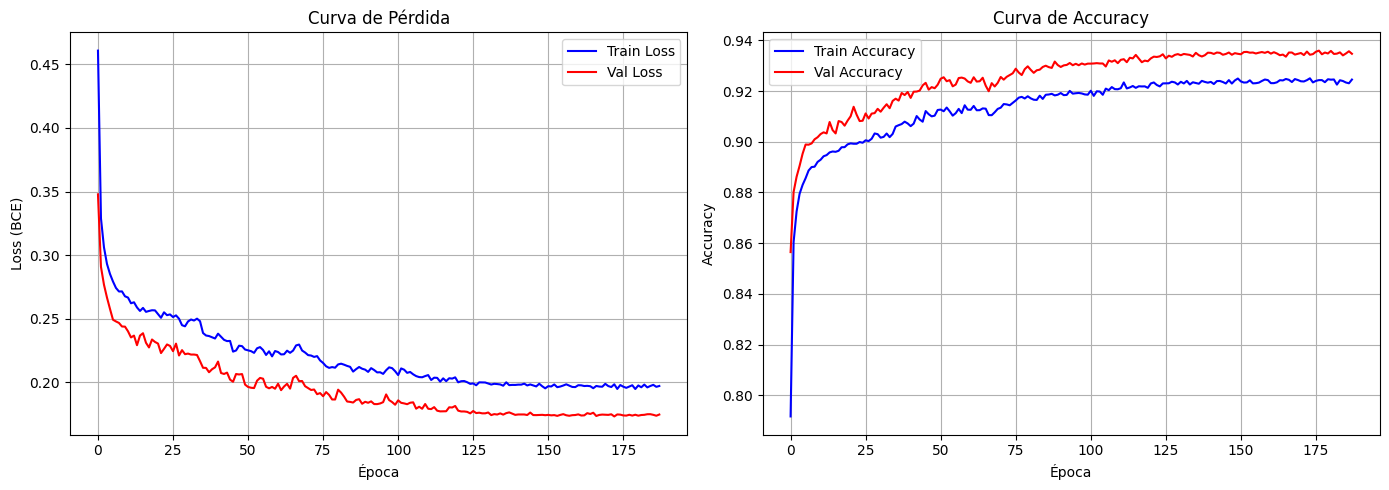

In [ ]:
# Graficar curvas de pérdida y accuracy
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de Loss
axes[0].plot(train_losses, label='Train Loss', color='blue')
axes[0].plot(val_losses, label='Val Loss', color='red')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss (BCE)')
axes[0].set_title('Curva de Pérdida')
axes[0].legend()
axes[0].grid(True)

# Gráfico de Accuracy
axes[1].plot(train_accs, label='Train Accuracy', color='blue')
axes[1].plot(val_accs, label='Val Accuracy', color='red')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Curva de Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 10. Cargar el Mejor Modelo (Checkpoint)

In [ ]:
# Cargar el mejor modelo desde el checkpoint
model_loaded = ClasificadorBinarioNN(n_features).to(device)
model_loaded.load_state_dict(torch.load(CHECKPOINT_PATH))
model_loaded.eval()

print("Modelo cargado desde checkpoint exitosamente!")

Modelo cargado desde checkpoint exitosamente!


## 11. Evaluación y Métricas

In [ ]:
def evaluar(model, test_loader, device):
    """
    Evalúa el modelo y retorna predicciones y valores reales.
    """
    model.eval()
    predicciones = []
    probabilidades = []
    reales = []

    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device)
            y_prob = model(x_batch)  # Probabilidades
            y_pred = (y_prob > 0.5).float()  # Clases predichas

            probabilidades.extend(y_prob.cpu().numpy())
            predicciones.extend(y_pred.cpu().numpy())
            reales.extend(y_batch.numpy())

    return np.array(predicciones), np.array(probabilidades), np.array(reales)

# Obtener predicciones
y_pred, y_prob, y_real = evaluar(model_loaded, test_loader, device)

In [ ]:
# Calcular métricas EN TEST (evaluación final real)
accuracy = accuracy_score(y_real, y_pred)
print(f"\n{'='*50}")
print(f"MÉTRICAS DE EVALUACIÓN EN TEST (datos nunca vistos)")
print(f"{'='*50}")
print(f"\nAccuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Reporte de clasificación
print(f"\nReporte de Clasificación:")
print(classification_report(y_real, y_pred, target_names=['Fondo (0)', 'Señal (1)']))


MÉTRICAS DE EVALUACIÓN EN TEST (datos nunca vistos)

Accuracy: 0.9299 (92.99%)

Reporte de Clasificación:
              precision    recall  f1-score   support

   Fondo (0)       0.94      0.92      0.93      4000
   Señal (1)       0.92      0.94      0.93      4000

    accuracy                           0.93      8000
   macro avg       0.93      0.93      0.93      8000
weighted avg       0.93      0.93      0.93      8000



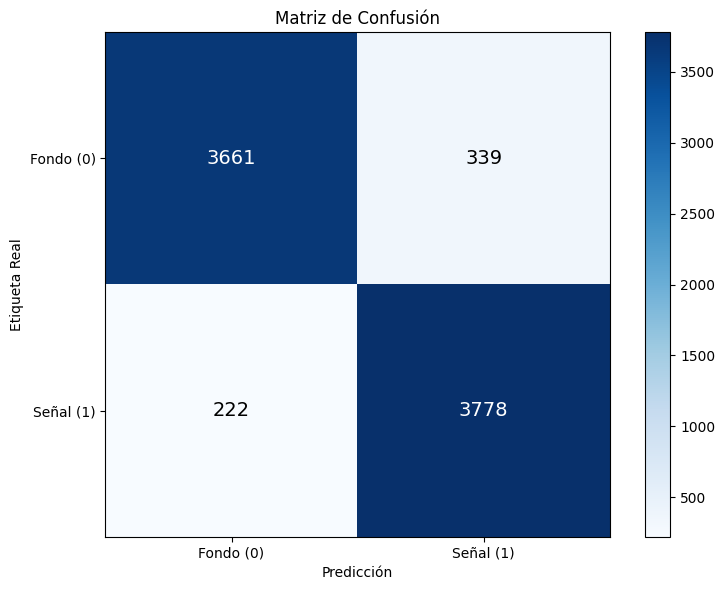


Verdaderos Negativos (TN): 3661
Falsos Positivos (FP): 339
Falsos Negativos (FN): 222
Verdaderos Positivos (TP): 3778


In [ ]:
# Matriz de confusión
cm = confusion_matrix(y_real, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Matriz de Confusión')
plt.colorbar()

classes = ['Fondo (0)', 'Señal (1)']
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)

# Añadir valores en cada celda
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black",
                 fontsize=14)

plt.ylabel('Etiqueta Real')
plt.xlabel('Predicción')
plt.tight_layout()
plt.show()

print(f"\nVerdaderos Negativos (TN): {cm[0,0]}")
print(f"Falsos Positivos (FP): {cm[0,1]}")
print(f"Falsos Negativos (FN): {cm[1,0]}")
print(f"Verdaderos Positivos (TP): {cm[1,1]}")

## 12. Predicción de Nuevo Evento

In [ ]:
def predecir_evento(model, caracteristicas, mu_X, sigma_X, device):
    """
    Predice si un evento es Señal o Fondo.

    Args:
        model: Modelo entrenado
        caracteristicas: numpy array con las 50 características del sensor
        mu_X, sigma_X: Media y desv. estándar de X (para normalizar)
        device: Dispositivo (cuda/cpu)

    Returns:
        Clase predicha (0 o 1) y probabilidad
    """
    model.eval()

    # Normalizar características
    x_norm = (caracteristicas - mu_X) / sigma_X
    x_tensor = torch.from_numpy(x_norm.astype(np.float32)).unsqueeze(0).to(device)

    # Predecir
    with torch.no_grad():
        probabilidad = model(x_tensor).cpu().numpy()[0][0]

    clase = 1 if probabilidad > 0.5 else 0

    return clase, probabilidad

In [ ]:
# Ejemplo: Predecir usando un evento del dataset de prueba
indice_ejemplo = 100

# Obtener un evento de test (ya normalizado) y desnormalizarlo
evento_normalizado = X_test[indice_ejemplo]
etiqueta_real = int(y_test[indice_ejemplo])

# Desnormalizar: x_original = x_norm * sigma + mu
evento_original = evento_normalizado * sigma_X + mu_X

clase_pred, prob = predecir_evento(
    model=model_loaded,
    caracteristicas=evento_original,
    mu_X=mu_X,
    sigma_X=sigma_X,
    device=device
)

print(f"\n{'='*50}")
print(f"PREDICCIÓN DE EVENTO")
print(f"{'='*50}")
print(f"Etiqueta Real: {'Señal (1)' if etiqueta_real == 1 else 'Fondo (0)'}")
print(f"Predicción: {'Señal (1)' if clase_pred == 1 else 'Fondo (0)'}")
print(f"Probabilidad de Señal: {prob:.4f} ({prob*100:.2f}%)")
print(f"Resultado: {'✓ CORRECTO' if clase_pred == etiqueta_real else '✗ INCORRECTO'}")
print(f"{'='*50}")


PREDICCIÓN DE EVENTO
Etiqueta Real: Señal (1)
Predicción: Señal (1)
Probabilidad de Señal: 0.8241 (82.41%)
Resultado: ✓ CORRECTO


/tmp/ipykernel_662/1627481184.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  etiqueta_real = int(y_test[indice_ejemplo])


## 13. Inspección de Pesos del Modelo

## 14. Resumen

### Conceptos Clave Implementados:

1. **`torch.utils.data.Dataset`**: Clase personalizada para datos de MiniBooNE
2. **`torch.utils.data.DataLoader`**: Iterador de batches con shuffle
3. **`torch.nn.Sequential`**: Definir red neuronal con múltiples capas
4. **`torch.nn.Linear`**: Capas lineales (fully connected)
5. **`torch.nn.ReLU`**: Función de activación no lineal
6. **`torch.nn.Sigmoid`**: Convierte salida a probabilidad [0, 1]
7. **`torch.nn.BCELoss`**: Binary Cross Entropy para clasificación binaria
8. **`torch.optim.Adam`**: Optimizador adaptativo
9. **Checkpoints**: Guardar/cargar modelos

### Comparación con Regresión Logística Tradicional:

| Aspecto | Tradicional (NumPy/SciPy) | PyTorch |
|---------|---------------------------|----------|
| Sigmoid | `1 / (1 + np.exp(-z))` | `nn.Sigmoid()` |
| Costo | Manual log-loss | `nn.BCELoss()` |
| Gradientes | `scipy.optimize` | `loss.backward()` |
| Capas ocultas | No soportado | `nn.Sequential(...)` |
| GPU | No soportado | `.to(device)` |

### Arquitectura de la Red:

```
Entrada (50 sensores) → Linear(64) → ReLU → Linear(32) → ReLU → Linear(1) → Sigmoid → Probabilidad
```